Joining & running PCA on all tables that don't require pivoting.

In [ ]:
import duckdb
from pathlib import Path
import pandas as pd

tables = ["ic", "ic_ay", "ic_py", "adm", "efia", "ef_d", "sfa", "gr200", "al", "f1a", "f2", "f3"]

current_script_parent = Path.cwd().parent
con = duckdb.connect(current_script_parent / "ipeds.duckdb")

# let's build the mega db
db = con.execute("SELECT * FROM hd WHERE year = 2023").fetchdf()

for table in tables:
    query = f"""SELECT * FROM {table} WHERE year = 2023""".format(table=table)
    table_df = con.execute(query).fetchdf()

    # remove any columns whose label starts with "x"
    table_df = table_df.drop(columns=table_df.filter(regex='^x').columns)

    # drop any columns that are all null
    table_df = table_df.dropna(axis=1, how='all')

    db = db.merge(table_df, on=["unitid", "year"], how="left")

# print the shape of the df
print(f"Final merged dataframe shape: {db.shape}")



Final merged dataframe shape: (6163, 1432)


unitid                  0.000000
institution_name        0.000000
ialias                  0.064903
addr                    0.000000
city                    0.000000
state                   0.000000
zip_code                0.000000
fips_state              0.000000
region                  0.000000
chfnm                   0.000000
chftitle                0.000000
gentele                 0.000000
ein                     0.000000
ueis                    0.000000
opeid                   0.000000
opeflag                 0.000000
website                 0.000000
adminurl                0.000000
faidurl                 0.000000
applurl                 0.000000
npricurl                0.000000
veturl                  0.000000
athurl                  0.000000
disaurl                 0.000000
sector                  0.000000
level                   0.000000
control                 0.000000
hloffer                 0.000000
ugoffer                 0.000000
groffer                 0.000000
hdegofr1  

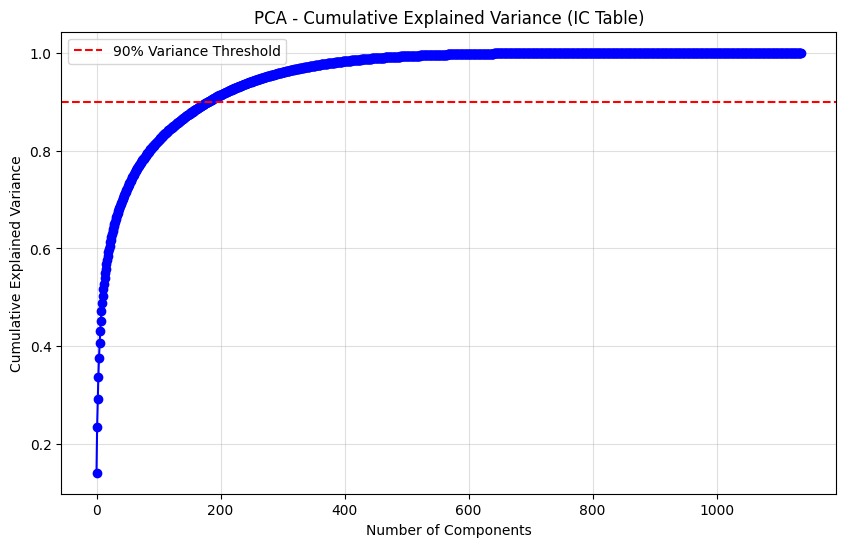

In [ ]:
db = db.dropna(axis=1, how='all')

# let's try a few strategies for handling these
imputation_strategy = "mean" # or "0" or "delete"

if imputation_strategy == "mean":
    db = db.fillna(db.mean(numeric_only=True))
elif imputation_strategy == "0":
    db = db.fillna(0)
elif imputation_strategy == "delete":
    db = db.dropna(axis=1)


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
nan_counts = db.isna().sum()
nan_percentage = (nan_counts / len(db)) * 100
display(nan_percentage)


import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Isolate numeric columns for PCA (exclude IDs and text metadata)
cols_to_exclude = ['unitid', 'year', 'institution_name', 'city', 'state', 'carnegie', 'sector', 'control']
numeric_cols = [col for col in db.columns if col not in cols_to_exclude and pd.api.types.is_numeric_dtype(db[col])]

X = db[numeric_cols].copy()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the PCA
pca = PCA()
df_pca = pca.fit_transform(X_scaled)

# lot the Cumulative Explained Variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-', color='b')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance (IC Table)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

In [17]:
import plotly.express as px

# Plot 2D PCA with highlighted institutions

df_cleaned = db.copy()

# Define the institutions to highlight by unitid 
highlight_unitids = [196866, # Union
                     165015, # Brandeis
                     196079, # Binghamton
                     194824, # RPI
                     195474, # Siena
                     195164, # Saint Bonaventure
                     191719, # HVCC
                     190150] # Columbia University


pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_cleaned['PC1'] = X_pca_2d[:, 0]
df_cleaned['PC2'] = X_pca_2d[:, 1]

df_cleaned['Peer_Group'] = 'All Other Institutions'
df_cleaned['Marker_Size'] = 5 

highlight_mask = df_cleaned['unitid'].isin(highlight_unitids)
df_cleaned.loc[highlight_mask, 'Peer_Group'] = df_cleaned['institution_name']
df_cleaned.loc[highlight_mask, 'Marker_Size'] = 15

df_cleaned = df_cleaned.sort_values('Marker_Size')

fig = px.scatter(
    df_cleaned,
    x='PC1',
    y='PC2',
    color='Peer_Group',
    size='Marker_Size', 
    size_max=15,       
    hover_name='institution_name',
    hover_data={
        'PC1': False,          
        'PC2': False,         
        'Peer_Group': False,  
        'Marker_Size': False,  
        'unitid': True,       
    },
    color_discrete_map={
        'All Other Institutions': 'lightgray'
    },
    title='2D Institutional Landscape (Hover for Details)',
    labels={
        'PC1': f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)',
        'PC2': f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)'
    }
)

fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')), opacity=0.8)
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgray', scaleratio=1),
    yaxis=dict(showgrid=True, gridcolor='lightgray', scaleratio=1),
)

fig.show()

--- Top 16 Peers Identified ---
 unitid                  institution_name
 134079          Florida Southern College
 143358                Bradley University
 150163                 Butler University
 165699                  Endicott College
 166850                 Merrimack College
 168227 Wentworth Institute of Technology
 185572               Monmouth University
 192819                    Marist College
 195474                     Siena College
 198516                   Elon University
 206622                 Xavier University
 209825            University of Portland
 215929            University of Scranton
 217518         Roger Williams University
 235316                Gonzaga University
 236595                Seattle University




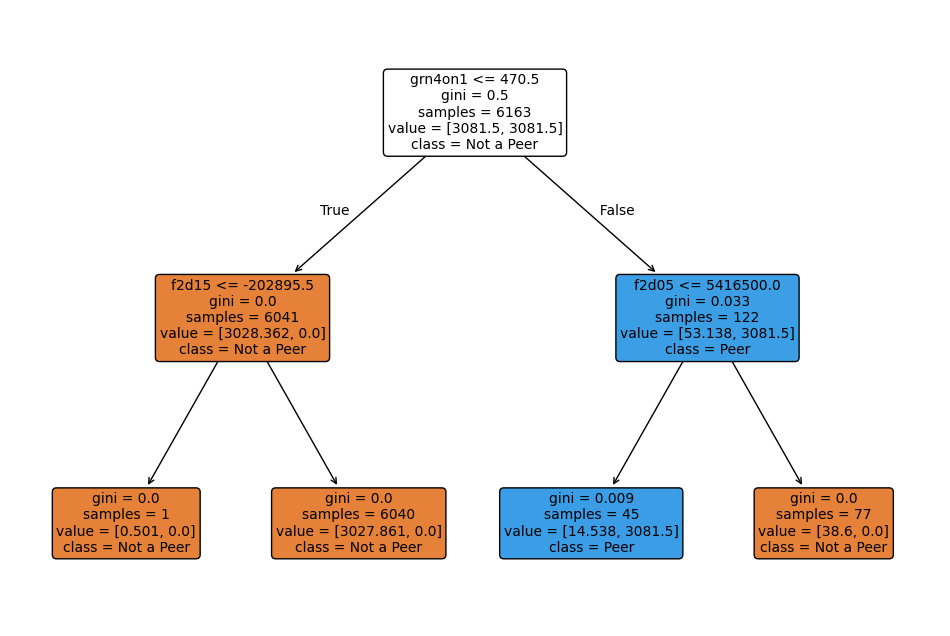

Accuracy: 0.9952944994320948
F1 Score: 0.5245901639344263


In [18]:
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import tree
from sklearn.metrics import accuracy_score, f1_score

# Restore df_cleaned to its original order before joining NumPy arrays!
df_cleaned = df_cleaned.sort_index()

# --- Configuration ---
target_unitids = [195474]
m_components = 38                  
n_peers = 15                      

# Run PCA with m dimensions
pca_m = PCA(n_components=m_components)
X_pca_m = pca_m.fit_transform(X_scaled)

# Find the "Centroid" of the target institutions in PCA space
# Get the row indices of our targets in the dataframe
target_indices = df_cleaned.index[df_cleaned['unitid'].isin(target_unitids)].tolist()

# Calculate the mean position of our targets across all m dimensions
centroid = X_pca_m[target_indices].mean(axis=0).reshape(1, -1)

# Find the n closest institutions to the centroid
knn = NearestNeighbors(n_neighbors=n_peers + len(target_unitids))
knn.fit(X_pca_m)
distances, indices = knn.kneighbors(centroid)

# Flatten the list of nearest neighbor indices
peer_indices = indices[0]

# Create the Machine Learning Dataset
df_ml = df_cleaned.copy()
df_ml['peer'] = 0 # Default everyone to 0

# Set the identified nearest neighbors to 1
df_ml.iloc[peer_indices, df_ml.columns.get_loc('peer')] = 1

# Let's peek at who the model selected!
selected_peers = df_ml[df_ml['peer'] == 1][['unitid', 'institution_name']]
print(f"--- Top {len(selected_peers)} Peers Identified ---")
print(selected_peers.to_string(index=False))
print("\n")

# Train the "Explainer" Decision Tree
tree_X = df_ml[numeric_cols]
tree_y = df_ml['peer']

# Max_depth=2 keeps it "heavily pruned"
clf = DecisionTreeClassifier(max_depth=2, class_weight='balanced', random_state=42)
clf.fit(tree_X, tree_y)

plt.figure(figsize=(12, 8))
tree.plot_tree(clf, 
               feature_names=numeric_cols,  
               class_names=['Not a Peer', 'Peer'], # <-- Fixed class names!
               filled=True,
               rounded=True,       # Rounds the corners of the boxes
               proportion=False,   # Change to True if you want percentages instead of decimal weights
               fontsize=10)
plt.show()

y_pred = clf.predict(tree_X)
y_true = tree_y

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {acc}")
print(f"F1 Score: {f1}")